In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, display_html, Markdown
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# 데이터 로드
grid = gpd.read_file('./data/01._격자_(4개_시·구).geojson')
grid_acc = pd.read_csv('grid_accident.csv')
grid_congestion = pd.read_csv('grid_congestion.csv')
grid_school = pd.read_csv('grid_school.csv')
grid_kinder = pd.read_csv('grid_kinder.csv')
grid_nursery = pd.read_csv('grid_nursery.csv')
grid_resident = pd.read_csv('grid_resident.csv')
grid_floating = pd.read_csv('grid_floating.csv')
grid_kukto = pd.read_csv('grid_kukto.csv')
grid_visit = pd.read_csv('grid_visit.csv')
grid_work = pd.read_csv('grid_work.csv')
grid_service = pd.read_csv('grid_service.csv')
grid_facility = pd.read_csv('grid_facility.csv')

# 사고 지수

수식 :$$\text{사고 점수} = \text{사고 심각도(EPDO)} \times \text{법규 위반 가중치} \times \text{교통 약자 가중치}$$
$$\text{사고 지수} = \log(1 + \sum \text{개별 사고 점수})$$

In [3]:
# 주요 컬럼 값 확인
df1 = grid_acc['violation'].value_counts().to_frame()
df2 = grid_acc['age_group'].value_counts().to_frame()
df1_styler = df1.style.set_table_attributes("style='display:inline; margin-right:20px;'").set_caption("법규 위반별 빈도")
df2_styler = df2.style.set_table_attributes("style='display:inline;'").set_caption("연령대별 빈도")

# 출력
display_html(df1_styler._repr_html_() + df2_styler._repr_html_(), raw=True)

,count
violation,
안전운전불이행,6100
안전거리미확보,1564
신호위반,1404
기타,709
교차로운행방법위반,548
보행자보호의무위반,320
중앙선침범,290
,count
age_group,


In [4]:
# 사고지수 생성

def calculate_index(row):

    # 1. 사고심각도(사용자 정의: 12, 5, 3, 1)
    severity_score = (row['dprs_cnt'] * 12 +
                      row['sep_cnt'] * 5 +
                      row['slp_cnt'] * 3 +
                      row['inj_aplcnt_cnt'] * 1)

    # 물피 사고 최소점수 1점 부여
    if severity_score == 0:
        severity_score = 1


    # 2. 약자 가중치 (12세 이하: 1.3, 60세 이상: 1.2)
    v_weight = 1.0
    if row['age_group'] == '12세 이하':
        v_weight = 1.3
    elif row['age_group'] in ('65세 이상','61-64세'):
        v_weight = 1.2


    # 3. 법규 위반 가중치 (high:1.5, middle:1.3, low:1.2, base:1)
    violation_map = {
        '신호위반': 1.5, '보행자보호의무위반': 1.5, '중앙선침범': 1.5,
        '교차로운행방법위반': 1.3,
        '안전거리미확보': 1.2
    }
    vio_weight = violation_map.get(row['violation'], 1.0)


    # 최종 점수
    return pd.Series([severity_score, v_weight, vio_weight], index=['severity_score', 'v_weight', 'vio_weight'])

# 함수 적용
grid_acc[['severity_score', 'v_weight', 'vio_weight']] = grid_acc.apply(calculate_index, axis=1)

# 최종 사고 점수(acc_score) 계산
grid_acc['acc_score'] = grid_acc['severity_score'] * grid_acc['v_weight'] * grid_acc['vio_weight']

# 결과 확인
display(grid_acc.head(10))
print(grid_acc.isnull().sum())


,acc_yr,acc_mon,week_type,acc_time,sgg,acc_type,violation,road_type,road_sttus,weather,...,dprs_cnt,sep_cnt,slp_cnt,inj_aplcnt_cnt,index_right,gid,severity_score,v_weight,vio_weight,acc_score
0,2024,1,주중,19시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,기타 - 기타,건조,맑음,...,0,0,1,0,9661.0,다사678312,3.0,1.0,1.0,3.0
1,2024,1,주중,07시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,기타 - 기타,건조,맑음,...,0,0,0,1,7458.0,다사663278,1.0,1.0,1.0,1.0
2,2024,1,주중,10시,경기도 성남시 분당구,차대차 - 기타,안전거리미확보,교차로 - 교차로부근,건조,맑음,...,0,1,0,0,9825.0,다사679345,5.0,1.0,1.2,6.0
3,2024,1,주중,17시,경기도 성남시 분당구,차대차 - 충돌,안전거리미확보,기타 - 기타,건조,맑음,...,0,1,0,0,5129.0,다사646334,5.0,1.0,1.2,6.0
4,2024,1,주중,23시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,교차로 - 교차로부근,건조,맑음,...,0,0,1,0,5536.0,다사649338,3.0,1.0,1.0,3.0
5,2024,1,주중,13시,경기도 성남시 분당구,차대차 - 기타,안전거리미확보,기타 - 기타,젖음/습기,흐림,...,0,0,1,0,7654.0,다사664329,3.0,1.0,1.2,3.6
6,2024,1,주중,15시,경기도 성남시 분당구,차대차 - 충돌,안전운전불이행,기타 - 기타,젖음/습기,눈,...,0,0,4,0,12060.0,다사697340,12.0,1.0,1.0,12.0
7,2024,1,주중,12시,경기도 성남시 분당구,차대차 - 충돌,안전거리미확보,교차로 - 교차로부근,건조,흐림,...,0,0,3,0,6453.0,다사656266,9.0,1.0,1.2,10.8
8,2024,1,주중,15시,경기도 성남시 분당구,차대차 - 추돌,안전운전불이행,단일로 - 기타,건조,맑음,...,0,0,1,0,6325.0,다사655279,3.0,1.0,1.0,3.0
9,2024,1,주중,16시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,기타 - 기타,건조,맑음,...,0,0,1,0,2074.0,다사618322,3.0,1.0,1.0,3.0


acc_yr              0
acc_mon             0
week_type           0
acc_time            0
sgg                 0
acc_type            0
violation           0
road_type           0
road_sttus          0
weather             0
attckr_vhcle        0
victim_vhcle      427
injury_svrity     427
age_group         427
dprs_cnt            0
sep_cnt             0
slp_cnt             0
inj_aplcnt_cnt      0
index_right         1
gid                 1
severity_score      0
v_weight            0
vio_weight          0
acc_score           0
dtype: int64


In [5]:
# acc_score 전처리


# log변환 (분포의 왜곡을 줄임)
grid_acc['acc_index'] = np.log1p(grid_acc['acc_score'])

# 정규화
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(grid_acc[['acc_index']])

# 결과를 다시 컬럼에 할당
grid_acc['acc_index_sc'] = scaled_data

# 결과 저장 (디렉토리 구조에 맞춰 features 폴더로 경로 설정)
grid_acc.to_csv("accdent_index.csv", index=False)
print("✔ accdent_index.csv 생성 완료")

✔ accdent_index.csv 생성 완료


# 교통 혼잡 지수
수식: $$\text{혼잡지수} = \text{속도저하율} \times \text{교통부하} + \text{혼잡강도지표}$$

In [6]:
# 산출전 데이터 정규화

# 혼잡강도 로그 변환 및 데이터 정규화
grid_congestion['log_intensity'] = np.log1p(grid_congestion['w_congestion_intensity'])

scaler = MinMaxScaler()
cols_to_scale = ['w_speed_reduction', 'traffic_load', 'log_intensity']
scaled_cols = ['scaled_speed', 'scaled_load', 'scaled_intensity']
grid_congestion[scaled_cols] = scaler.fit_transform(grid_congestion[cols_to_scale])

# 혼잡지수 산출
grid_congestion['congestion_index'] = (
    (grid_congestion['scaled_speed'] * grid_congestion['scaled_load']) + grid_congestion['scaled_intensity']
)


# gid별 최종 혼잡지수 평균 산출

mean_congestion_df = grid_congestion.groupby('gid', as_index=False)['congestion_index'].mean()
mean_congestion_df.rename(columns={'congestion_index': 'mean_congestion_index'}, inplace=True)

# geometry와 다시 결합 (시각화위해)
final_mean_gdf = grid[['gid', 'geometry']].merge(mean_congestion_df, on='gid', how='inner')

# 결과 확인 및 저장
# 순수 수치 데이터만 CSV로 저장
pd.DataFrame(final_mean_gdf.drop(columns='geometry')).to_csv('congestion_index.csv', index=False, encoding='utf-8-sig')
print("✔ congestion_index.csv 생성 완료")

✔ congestion_index.csv 생성 완료



### 🚦 교통 혼잡지수(mean_congestion_index) 분포 요약
---
* **분석 단위:** 격자(gid) 기준 시간대별 평균
* **총 분석 격자 수:** 99,146개
* **파일이름:** `'congestion_index.csv'`
---


📈 [기초 통계량]


,count,mean,std,min,25%,50%,75%,max,std_dev
mean_congestion_index,99146.0000,0.2107,0.3673,0.0000,0.0000,0.0000,0.3738,1.3834,0.3673


---


🚨 [Top 10] 교통 혼잡도가 가장 높은 격자


,gid,mean_congestion_index
94481,다사739479,1.3834
94602,다사740480,1.2943
94482,다사739480,1.2208
92116,다사722501,1.1545
94720,다사741480,1.1534
75298,다사650359,1.1533
76149,다사653359,1.1524
74746,다사648359,1.1410
81486,다사671371,1.1397
94601,다사740479,1.1281


---

<Figure size 1500x1200 with 0 Axes>

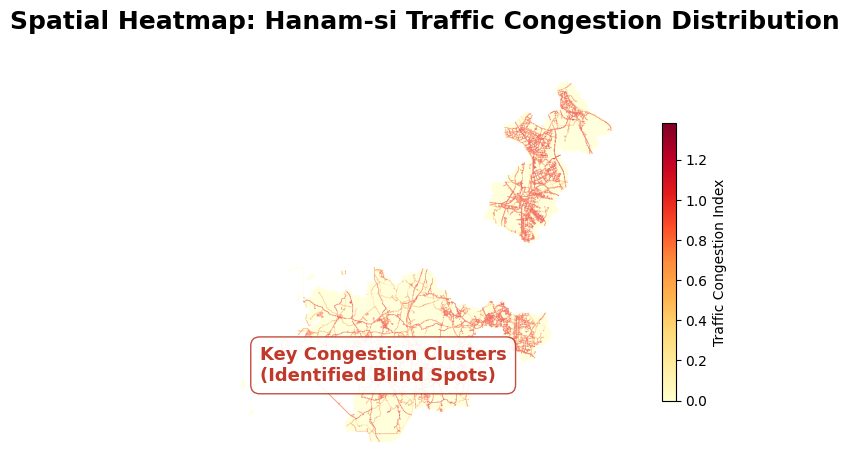

---

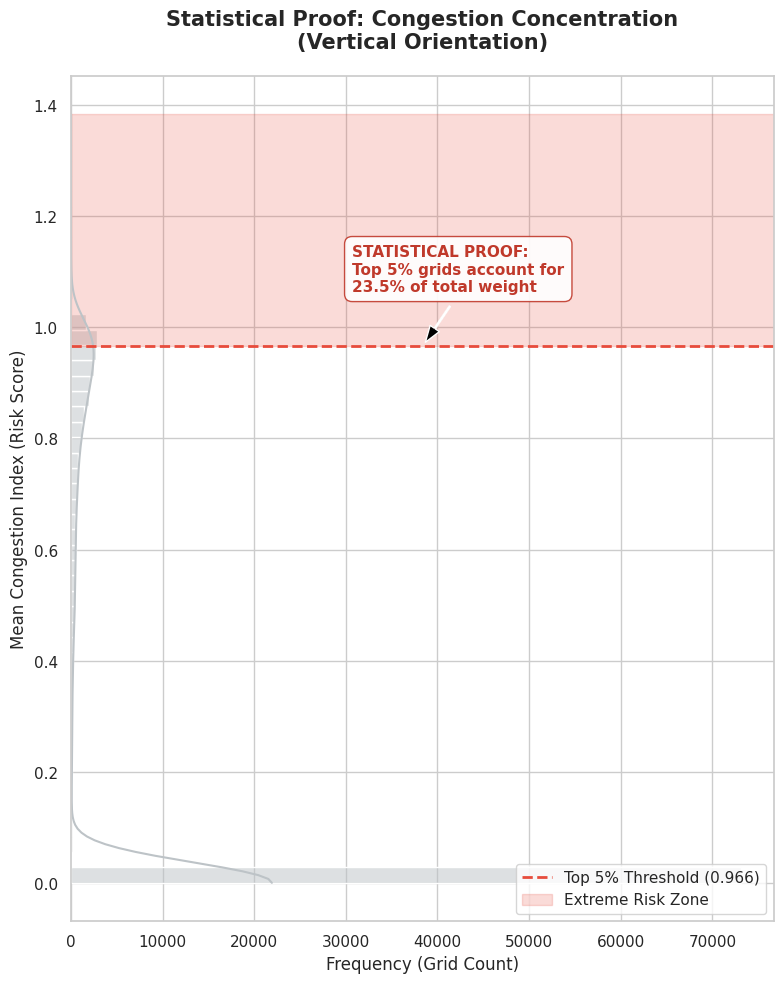

In [7]:
# 시각화 

# Markdown
display(Markdown(f"""
### 🚦 교통 혼잡지수(mean_congestion_index) 분포 요약
---
* **분석 단위:** 격자(gid) 기준 시간대별 평균
* **총 분석 격자 수:** {len(mean_congestion_df):,}개
* **파일이름:** `'congestion_index.csv'`
---
"""))

# 기초 통계량
print("📈 [기초 통계량]")
stats_df = mean_congestion_df['mean_congestion_index'].describe().to_frame().T
stats_df['std_dev'] = mean_congestion_df['mean_congestion_index'].std()

styled_stats = stats_df.style.format('{:.4f}')\
    .set_properties(**{'background-color': '#f4f4f4', 'color': 'black'})\
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#444444'), ('color', 'white')]}])

display(styled_stats)
display(Markdown('---'))

# 상위 10개 혼잡 지역
print("\n🚨 [Top 10] 교통 혼잡도가 가장 높은 격자")
top_10_congestion = (mean_congestion_df[['gid', 'mean_congestion_index']]
                     .sort_values(by='mean_congestion_index', ascending=False)
                     .head(10)
                     .style
                     .format({'mean_congestion_index': '{:.4f}'})
                     .background_gradient(cmap='OrRd', subset=['mean_congestion_index']) # 높을수록 진한 빨간색
                     .set_properties(**{'text-align': 'center'})
                    )

display(top_10_congestion)
display(Markdown('---'))

# 공간적 히트맵(사각지대 정체구역 증명)
plt.figure(figsize=(15, 12), facecolor='white')
ax = final_mean_gdf.plot(column='mean_congestion_index', 
                         cmap='YlOrRd',
                         legend=True,
                         legend_kwds={'label': "Traffic Congestion Index", 
                                       'orientation': "vertical",
                                       'shrink': 0.7},
                         edgecolor='none',
                         alpha=0.9)
plt.title('Spatial Heatmap: Hanam-si Traffic Congestion Distribution', 
          fontsize=18, fontweight='bold', pad=25)
plt.axis('off')
plt.annotate('Key Congestion Clusters\n(Identified Blind Spots)', 
             xy=(0.1, 0.2), xycoords='axes fraction', 
             fontsize=13, color='#c0392b', fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#c0392b", alpha=0.9))
plt.tight_layout()
plt.show()
display(Markdown('---'))

# 혼잡의 집중도
data = final_mean_gdf['mean_congestion_index']
threshold_95 = data.quantile(0.95)
top_5_sum = data[data >= threshold_95].sum()
total_sum = data.sum()
concentration_ratio = (top_5_sum / total_sum) * 100

plt.figure(figsize=(8, 10), facecolor='white') # 세로로 길게 설정
sns.set_theme(style="whitegrid")
sns.histplot(y=data, bins=50, kde=True, color='#bdc3c7', alpha=0.5)

plt.axhline(threshold_95, color='#e74c3c', linestyle='--', linewidth=2, 
            label=f'Top 5% Threshold ({threshold_95:.3f})')
plt.axhspan(threshold_95, data.max(), color='#e74c3c', alpha=0.2, label='Extreme Risk Zone')
plt.annotate(f'STATISTICAL PROOF:\nTop 5% grids account for\n{concentration_ratio:.1f}% of total weight', 
             xy=(plt.gca().get_xlim()[1]*0.5, threshold_95), 
             xytext=(plt.gca().get_xlim()[1]*0.4, threshold_95 + 0.1),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=8),
             fontsize=11, fontweight='bold', color='#c0392b',
             bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#c0392b", alpha=0.9))
plt.title('Statistical Proof: Congestion Concentration\n(Vertical Orientation)', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Mean Congestion Index (Risk Score)', fontsize=12)
plt.xlabel('Frequency (Grid Count)', fontsize=12)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 취약수요지수

수식 : 비례 할당 기법으로 $V_{val}$ (실질 활동 취약 인구) 산출 후, 계산
 $$VDI = \frac{\sum V_{val}}{Total\_Activity\_Pop}$$

###  - 유아, 초등 유동인구 추정
- 어린이 유동인구 데이터의 공백을 시설데이터의 인가정원수치로 추정

In [8]:
# 시설별 인가 정원수
AVG_ELEM_CAP = 600 # KESS 공공데이터 기반 초등학교 인가정원수
grid_school['est_floating_elem'] = grid_school['cnt_school'] * AVG_ELEM_CAP
grid_kinder['est_floating_kinder'] = grid_kinder['total_kinder_cap']
grid_nursery['est_floating_nursery'] = grid_nursery['total_nursery_cap']

# 어린이 유동인구 데이터 통합
child_floating = grid_school[['gid', 'lat', 'lon', 'est_floating_elem']].copy()
child_floating = pd.merge(child_floating,grid_kinder[['gid', 'est_floating_kinder']],on='gid', how='left')
child_floating = pd.merge(child_floating,grid_nursery[['gid', 'est_floating_nursery']],on='gid', how='left')
child_floating = child_floating.fillna(0)

# 전체 합계
child_floating['total_child_floating'] = (child_floating['est_floating_elem'] + child_floating['est_floating_kinder'] + child_floating['est_floating_nursery'])

# 결과 저장
print("✔ child_floating.csv 생성 완료 (시설별(초등/유치원/어린이집) 유동인구 추정)")
child_floating.to_csv('child_floating.csv', index=False, encoding='utf-8-sig')

✔ child_floating.csv 생성 완료 (시설별(초등/유치원/어린이집) 유동인구 추정)


### - 지수 산출

In [9]:
# 취약인구 데이터 통합

# 취약 유동인구 + 취약 거주인구
final_floating_pop = pd.merge(child_floating,grid_floating[['gid', 'avg_floating_senior', 'avg_floating_pop']],on='gid',how='left').fillna(0)
final_res_pop = pd.merge(grid_kukto.drop(columns=['lat', 'lon']), grid_resident, on='gid', how='outer').fillna(0)

final_pop = pd.merge(final_floating_pop.drop(columns=['lat', 'lon']), final_res_pop, on='gid', how='left').fillna(0)
final_pop['v_pop'] = (
    (final_pop['res_infant'] + final_pop['est_floating_kinder'] + final_pop['est_floating_nursery']) +
    (final_pop['res_child'] + final_pop['est_floating_elem']) +
    (final_pop['resident_senior_pop'] + final_pop['avg_floating_senior'])
)


# 데이터별 취약인구 산출

# 취약비율 계산
final_pop['base_total_pop'] = final_pop['resident_total_pop'] + final_pop['avg_floating_pop']
final_pop['v_ratio'] = (final_pop['v_pop'] / final_pop['base_total_pop']).fillna(0)

# 비례 할당 추정 기법
def merge_and_calc_v(final_pop, target_configs , ratio_col='v_ratio'):
    """
    final_pop: 유동+거주 데이터(v_ratio 포함)
    target_grids: [(집계완료df, '인구컬럼명', '분류명'), ...]
    ratio_col: 취약비율
    """
    final_df = final_pop.copy()

    for df, pop_col, category in target_configs:
        temp_df = df[['gid', pop_col]].rename(columns={pop_col: f'{category}_pop'})
        final_df = pd.merge(final_df, temp_df, on='gid', how='left').fillna(0)

        final_df[f'v_{category}'] = final_df[f'{category}_pop'] * final_df[ratio_col]

    return final_df

pop_configs = [(grid_visit, 'avg_visit_pop', 'visit'),(grid_work, 'avg_work_pop', 'work'),(grid_service, 'avg_service_pop', 'service')]
final_master = merge_and_calc_v(final_pop, pop_configs)

In [10]:
# 전체 취약인구, 전체 활동인구
final_master['total_v_val'] = final_master['v_pop'] +final_master['v_visit'] +final_master['v_work'] +(0.5 * final_master['v_service'])
final_master['total_activity_pop'] = final_master['resident_total_pop'] +final_master['avg_floating_pop'] +final_master['visit_pop'] +final_master['work_pop'] +(0.5 * final_master['service_pop'])

# 취약 인구 수요 지수 산출
final_master['v_demand_index'] = (final_master['total_v_val'] / final_master['total_activity_pop']).fillna(0)

# 데이터 보정
final_master['v_demand_log'] = np.log1p(final_master['v_demand_index'])
upper_limit = final_master['v_demand_log'].quantile(0.99)
final_master['v_demand_clipped'] = final_master['v_demand_log'].clip(upper=upper_limit)

v_min = final_master['v_demand_clipped'].min()
v_max = final_master['v_demand_clipped'].max()

final_master['v_demand_sc'] = (final_master['v_demand_clipped'] - v_min) / (v_max - v_min)

# 결과 저장
final_master[['gid', 'lon', 'lat', 'v_demand_sc', 'total_v_val', 'total_activity_pop']].to_csv(
    'vulnerable_demand_index.csv', index=False, encoding='utf-8-sig'
)
print("✔ 저장 완료: vulnerable_demand_index.csv")

✔ 저장 완료: vulnerable_demand_index.csv



## 💡 분석 요약

1. **지수 정밀도 확보**: 학교 및 어린이집 인가 정원 데이터를 활용하여 통계에 잡히지 않는 **'어린이 유동 수요'** 를 성공적으로 추정하였습니다.
2. **데이터 신뢰성 검증**: 국토정보맵과의 상관계수가 **0.9874** 로 나타나, 분석의 기초가 되는 인구 데이터의 신뢰성을 입증하였습니다.
3. **결론**: 최종 산출된 **취약수요지수(VDI)** 는 격자별 물리적 위험 노출도를 결정하는 변수로 활용됩니다.


---

### 🏆 교통취약 수요지수 산출 결과 (Top 10)

,gid,total_v_val,total_activity_pop,v_demand_sc
119620,다사363061,15.140647,0.461012,1.000000
147390,다사504104,132.558164,4.001218,1.000000
41215,다사682451,1562.608346,35.938108,1.000000
41214,다사682451,1562.608346,35.938108,1.000000
41213,다사682451,1562.608346,35.938108,1.000000
106884,다사264079,25.074238,0.864877,1.000000
41212,다사682451,1562.608346,35.938108,1.000000
41211,다사682451,1562.608346,35.938108,1.000000
106863,다사263159,16.774855,2.372233,1.000000
41210,다사682451,1562.608346,35.938108,1.000000


---

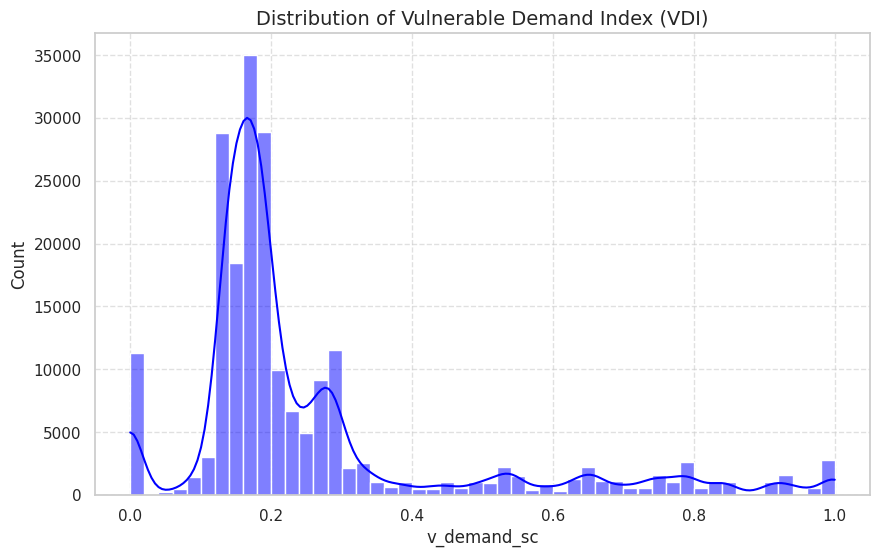

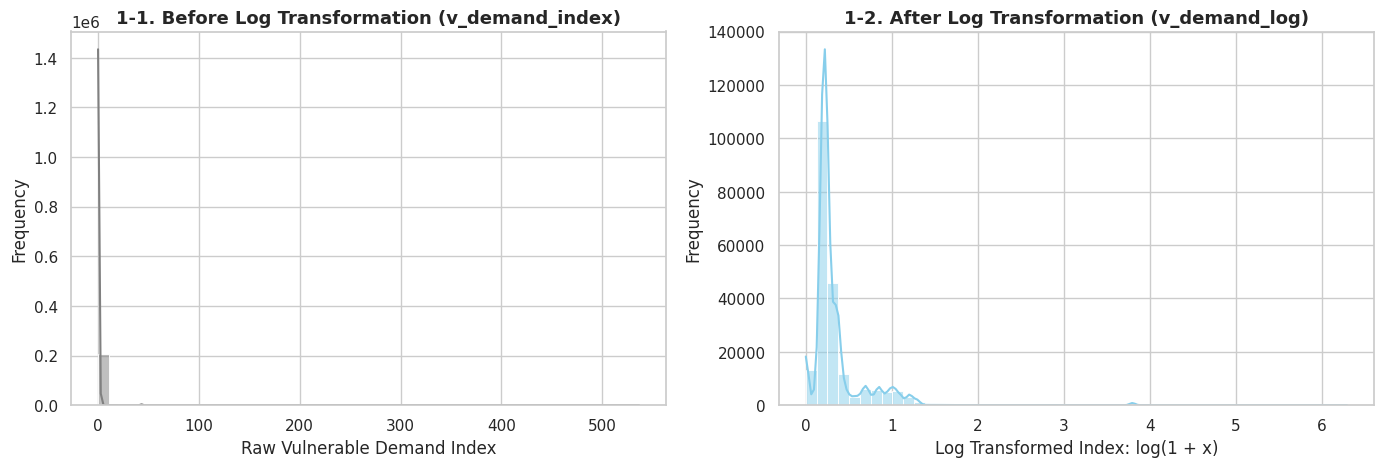

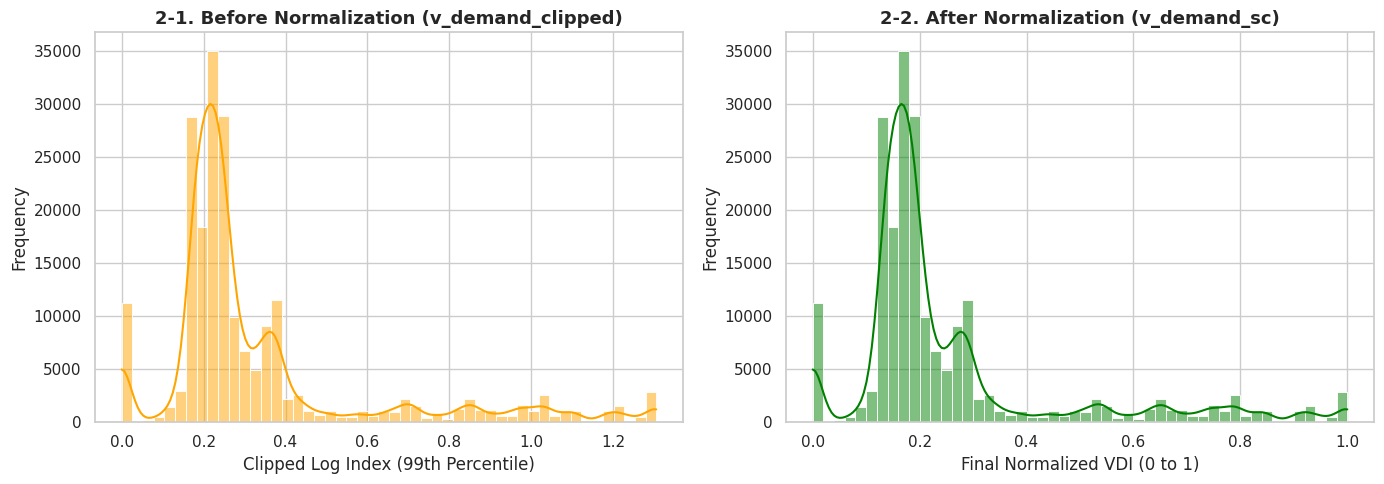

In [11]:
# 시각화

# 분포 요약
display(Markdown(f"""
## 💡 분석 요약

1. **지수 정밀도 확보**: 학교 및 어린이집 인가 정원 데이터를 활용하여 통계에 잡히지 않는 **'어린이 유동 수요'** 를 성공적으로 추정하였습니다.
2. **데이터 신뢰성 검증**: 국토정보맵과의 상관계수가 **0.9874** 로 나타나, 분석의 기초가 되는 인구 데이터의 신뢰성을 입증하였습니다.
3. **결론**: 최종 산출된 **취약수요지수(VDI)** 는 격자별 물리적 위험 노출도를 결정하는 변수로 활용됩니다.
"""))
display(Markdown("---"))
display(Markdown("### 🏆 교통취약 수요지수 산출 결과 (Top 10)"))
styled_table = (final_master.sort_values(by='v_demand_sc', ascending=False).head(10)
                [['gid', 'total_v_val', 'total_activity_pop', 'v_demand_sc']]
                .style.background_gradient(cmap='OrRd', subset=['v_demand_sc'])
                .set_properties(**{'text-align': 'center'}))
display(styled_table)

display(Markdown("---"))


# 분포
plt.figure(figsize=(10, 6), facecolor='white')
sns.histplot(final_master['v_demand_sc'], bins=50, kde=True, color='blue')
plt.title('Distribution of Vulnerable Demand Index (VDI)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 정규화 전후 비교
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

### 1. Log Transformation Comparison ###
plt.figure(figsize=(14, 5))

# 로그 변환 전 (v_demand_index)
plt.subplot(1, 2, 1)
sns.histplot(final_master['v_demand_index'], bins=50, kde=True, color='gray')
plt.title('1-1. Before Log Transformation (v_demand_index)', fontsize=13, fontweight='bold')
plt.xlabel('Raw Vulnerable Demand Index')
plt.ylabel('Frequency')
# 로그 변환 후 (v_demand_log)
plt.subplot(1, 2, 2)
sns.histplot(final_master['v_demand_log'], bins=50, kde=True, color='skyblue')
plt.title('1-2. After Log Transformation (v_demand_log)', fontsize=13, fontweight='bold')
plt.xlabel('Log Transformed Index: log(1 + x)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### 2. Normalization Comparison ###
plt.figure(figsize=(14, 5))

# 정규화 전 (v_demand_clipped)
plt.subplot(1, 2, 1)
sns.histplot(final_master['v_demand_clipped'], bins=50, kde=True, color='orange')
plt.title('2-1. Before Normalization (v_demand_clipped)', fontsize=13, fontweight='bold')
plt.xlabel('Clipped Log Index (99th Percentile)')
plt.ylabel('Frequency')
# 정규화 후 (v_demand_sc)
plt.subplot(1, 2, 2)
sns.histplot(final_master['v_demand_sc'], bins=50, kde=True, color='green')
plt.title('2-2. After Normalization (v_demand_sc)', fontsize=13, fontweight='bold')
plt.xlabel('Final Normalized VDI (0 to 1)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# 안전 시설 미비 지수

수식:
$$\text{시설 지수} = \frac{(\text{횡단보도 수} + \text{CCTV 수} + \text{방지턱 수}) \times (1 + w(\text{보호구역 여부}))}{\text{격자 면적}}$$

$$\text{안전 미비 시설 지수} = 1 - \text{시설지수}$$

In [12]:
# 시설 점수 계산



# 보호구역 가중치 설정
zone_w = 0.4

grid_facility['facility_raw'] = (
    grid_facility['cctv_cnt']
    + grid_facility['cross_cnt']
    + grid_facility['bump_cnt']
)

grid_facility['facility_score'] = grid_facility['facility_raw'] * (1 + zone_w * grid_facility['zone_flag'])

# 정규화
scaler = MinMaxScaler()
grid_facility['facility_index'] = scaler.fit_transform(grid_facility[['facility_score']])

# 안전시설미비지수 생성
grid_facility['facility_lack_index'] = 1 - grid_facility['facility_index']

# 저장
grid_facility.to_csv('facility_lack_index.csv', index=False, encoding='utf-8-sig')
print("✔ 저장 완료: facility_lack_index.csv")

✔ 저장 완료: facility_lack_index.csv


In [13]:
# 시각화

# 분포 요약
display(Markdown(f"""
### 📊 시설 지수(facility_lack_index) 분포 요약
---
* **전체 격자 수:** {len(grid_facility):,}개
* **파일 이름:** `facility_lack_index.csv`
---
"""))

# 기초통계량
stats_df = grid_facility['facility_lack_index'].describe().to_frame().T
stats_df['std_dev'] = grid_facility['facility_lack_index'].std() 

print("📈 [기초 통계량]")
styled_stats = stats_df.style.format('{:.4f}')\
    .set_properties(**{'background-color': '#f9f9f9', 'color': 'black', 'border-color': 'white'})\
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#606060'), ('color', 'white')]}])

display(styled_stats)

# 상위 10개 격자 출력
print("\n🏆 [Top 10] 시설 지수가 가장 높은 격자")
top_10_styled = (grid_facility[['gid', 'facility_lack_index']]
                 .sort_values(by='facility_lack_index', ascending=False)
                 .head(10)
                 .style
                 .format({'facility_lack_index': '{:.4f}'})
                 .background_gradient(cmap='YlGnBu', subset=['facility_lack_index']) # 높은 점수일수록 진한 파랑
                 .set_properties(**{'text-align': 'center'})
                )

display(top_10_styled)


### 📊 시설 지수(facility_lack_index) 분포 요약
---
* **전체 격자 수:** 99,323개
* **파일 이름:** `facility_lack_index.csv`
---


📈 [기초 통계량]


,count,mean,std,min,25%,50%,75%,max,std_dev
facility_lack_index,99323.0000,0.9903,0.0360,0.0000,1.0000,1.0000,1.0000,1.0000,0.0360



🏆 [Top 10] 시설 지수가 가장 높은 격자


,gid,facility_lack_index
0,다사581304,1.0000
61901,다사423044,1.0000
61921,다사423064,1.0000
61920,다사423063,1.0000
61919,다사423062,1.0000
61918,다사423061,1.0000
61917,다사423060,1.0000
61916,다사423059,1.0000
61915,다사423058,1.0000
61914,다사423057,1.0000


# 현재 위험도 지수

수식:
$$\text{현재위험도 지수} = w_1(\text{교통혼잡지수}) + w_2(\text{안전시설미비지수}) + w_3(\text{취약수요지수}) + w_4(\text{사고지수})$$

 - 로짓 회귀의 **통계적 유의성(영향력)** 과 엔트로피의 **데이터 변별력(정보량)** 을 결합하여 객관적 통합 가중치를 도출함.
 
$$w_4 = 0.4$$, $$w_1 + w_2 + w_3 = 0.6$$
 - 사고지수는 현재 위험도 지수를 설명하는 가장 중요한 지표이므로 가중치를 고정함. 이외 다른 지표들의 가중치 합을 **환경가중치** 0.6으로 지정함.

In [14]:
# 데이터 로드
acc = pd.read_csv('accdent_index.csv')
con = pd.read_csv('congestion_index.csv')
demand = pd.read_csv('vulnerable_demand_index.csv')
fc = pd.read_csv('facility_lack_index.csv')

# 데이터셋 생성
# 취약계층 사고 발생 유무 타겟 생성
vulnerable_conditions = ['12세 이하', '61-64세', '65세 이상']
v_acc = grid_acc[grid_acc['age_group'].isin(vulnerable_conditions)].copy()

acc_occur = v_acc.groupby('gid').size().reset_index(name='acc_count')
df_model = pd.merge(grid[['gid']], acc_occur, on='gid', how='left').fillna(0)
df_model['target'] = (df_model['acc_count'] > 0).astype(int)

# 분석용 Feature 병합
df_model = df_model.merge(fc[['gid', 'facility_lack_index']], on='gid') \
                   .merge(con[['gid', 'mean_congestion_index']], on='gid') \
                   .merge(demand[['gid', 'v_demand_sc']], on='gid') \
                   .merge(acc[['gid', 'acc_index_sc']], on='gid')

In [15]:
# 개별 로지스틱 회귀(변수 유의성 검정)

# 회귀변수 표준화
FEATURES = ['mean_congestion_index', 'facility_lack_index', 'v_demand_sc']
scaler_sd = StandardScaler()
df_sc = pd.DataFrame(scaler_sd.fit_transform(df_model[FEATURES]), columns=FEATURES)
df_sc['target'] = df_model['target'].values

# 분석
logit_results = []
for col in FEATURES:
    X = sm.add_constant(df_sc[[col]])
    y = df_sc['target']
    model = sm.Logit(y, X).fit(disp=0)

    p_val = model.pvalues[1]
    coef = model.params[1]
    std_err = model.bse[1]
    z_score = model.tvalues[1]

    logit_results.append({
        '지표명': col,
        'Coefficient': round(coef, 4),      # 회귀 계수
        'Std.Err': round(std_err, 4),       # 표준 오차
        'z-score': round(z_score, 4),       # z 통계량
        'P-value(10f)': f"{p_val:.10f}",    # 소수점 10자리까지 표시
        'P-value(Sci)': f"{p_val:.2e}",     # 과학적 표기법 (e-xx)
        '상태': '유의(p<0.05)' if p_val < 0.05 else '비유의'
    })

df_logit_res = pd.DataFrame(logit_results)
display(Markdown("### 🔍 변수 유의성 검정 결과"))
display(df_logit_res)

### 🔍 변수 유의성 검정 결과

,지표명,Coefficient,Std.Err,z-score,P-value(10f),P-value(Sci),상태
0,mean_congestion_index,-0.2313,0.0011,-213.6272,0.0000000000,0.00e+00,유의(p<0.05)
1,facility_lack_index,-0.7941,0.0012,-679.7129,0.0000000000,0.00e+00,유의(p<0.05)
2,v_demand_sc,0.7032,0.0010,676.7937,0.0000000000,0.00e+00,유의(p<0.05)


In [16]:
# 회귀 계수 절대값 기반 환경 가중치 산출

# 로짓 결과에서 계수(Coefficient)의 절대값을 중요도로 환산
df_logit_res['Abs_Coef'] = df_logit_res['Coefficient'].abs()
total_abs_coef = df_logit_res['Abs_Coef'].sum()

# 환경 지표 내 상대적 기여도 산출
df_logit_res['Relative_Importance'] = df_logit_res['Abs_Coef'] / total_abs_coef

# 최종 환경 가중치 정의 (60%)
df_logit_res['Final_Weight'] = df_logit_res['Relative_Importance'] * 0.6

# w1, w2, w3 정의
weight_map = dict(zip(df_logit_res['지표명'], df_logit_res['Final_Weight']))

w1 = weight_map.get('mean_congestion_index', 0)
w2 = weight_map.get('facility_lack_index', 0)
w3 = weight_map.get('v_demand_sc', 0)
w4 = 0.4  # 사고지수 고정 비중

# 최종 수식
final_formula = f"현재위험도 = ({w1:.4f} * 혼잡) + ({w2:.4f} * 시설미비) + ({w3:.4f} * 취약수요) + ({w4:.4f} * 사고지수)"

In [17]:
# 현재 위험도 지수 산출

#  표준화 (0-1)
def min_max_scale(col):
    if (col.max() - col.min()) == 0: return col
    return (col - col.min()) / (col.max() - col.min())

# 분석 데이터프레임(df_model) 복사 및 스케일링 적용
final_df = df_model.copy()
final_df['s_congestion'] = min_max_scale(final_df['mean_congestion_index'])
final_df['s_facility'] = min_max_scale(final_df['facility_lack_index'])
final_df['s_demand'] = min_max_scale(final_df['v_demand_sc'])
final_df['s_accident'] = min_max_scale(final_df['acc_index_sc'])

# 현재 위험도(Current Risk) 산출
final_df['current_risk'] = (
    (w1 * final_df['s_congestion']) +
    (w2 * final_df['s_facility']) +
    (w3 * final_df['s_demand']) +
    (w4 * final_df['s_accident'])
)

# 결과 저장
result = final_df.sort_values(by='current_risk', ascending=False)
result.to_csv('current_risk_index.csv', index=False, encoding='utf-8-sig')

---

### ⚖️ 로짓 계수 기반 최종 가중치 산출 결과

,지표명,Coefficient,Abs_Coef,Final_Weight
0,mean_congestion_index,-0.2313,0.2313,0.080285
1,facility_lack_index,-0.7941,0.7941,0.275633
2,v_demand_sc,0.7032,0.7032,0.244082



**분석 결과 요약:**
- 로짓 회귀 결과 모든 변수가 통계적으로 매우 유의함($p < 0.05$)이 확인되었습니다.
- 데이터 분포 편향이 심한 엔트로피법 대신, 모델이 입증한 **통계적 영향력(계수 절대값)**을 가중치의 근거로 채택하였습니다.
- 이를 통해 '시설 미비' 변수의 기여도를 충분히 확보하여 정책적 대안 제시의 타당성을 높였습니다.

**최종 가중치 및 수식:**
- **교통 혼잡 가중치 ($w_1$):** `0.0803`
- **시설 미비 가중치 ($w_2$):** `0.2756`
- **취약 수요 가중치 ($w_3$):** `0.2441`
- **사고 이력 가중치 ($w_4$):** `0.4000` (Fixed)
- **최종 수식:**
> **`현재위험도 = (0.0803 * 혼잡) + (0.2756 * 시설미비) + (0.2441 * 취약수요) + (0.4000 * 사고지수)`**
- **파일 이름:** `current_risk_index.csv`


---

### 🏆 교통취약 현재위험도 산출 결과 (상위 10개)

,gid,acc_count,target,facility_lack_index,mean_congestion_index,v_demand_sc,acc_index_sc,s_congestion,s_facility,s_demand,s_accident,current_risk
401,다사648310,1.000000,1,1.000000,0.922057,0.137880,1.000000,0.712399,1.000000,0.137880,1.000000,0.766482
92443,다사677367,3.000000,1,0.977778,0.767949,0.495771,0.811041,0.593332,0.967742,0.495771,0.811041,0.759803
5671771,다사730479,0.000000,0,1.000000,0.998725,0.743468,0.570827,0.771634,1.000000,0.743468,0.570827,0.747382
100672,다사678301,1.000000,1,1.000000,0.810302,0.471459,0.751861,0.626055,1.000000,0.471459,0.751861,0.741715
173,다사643338,0.000000,0,1.000000,0.770337,0.137099,0.956604,0.595177,1.000000,0.137099,0.956604,0.739522
5672633,다사380085,1.000000,1,0.977778,0.987620,0.213841,0.864077,0.763054,0.967742,0.213841,0.864077,0.725829
5672040,다사743485,1.000000,1,1.000000,0.861514,0.393837,0.739817,0.665622,1.000000,0.393837,0.739817,0.721128
1222,다사662325,0.000000,0,1.000000,0.993761,0.606624,0.586356,0.767799,1.000000,0.606624,0.586356,0.719884
1312,다사664300,0.000000,0,1.000000,0.837727,0.597742,0.608000,0.647244,1.000000,0.597742,0.608000,0.716695
240262,다사684373,1.000000,1,0.968889,0.000000,1.000000,0.517563,0.000000,0.954839,1.000000,0.517563,0.714292


---

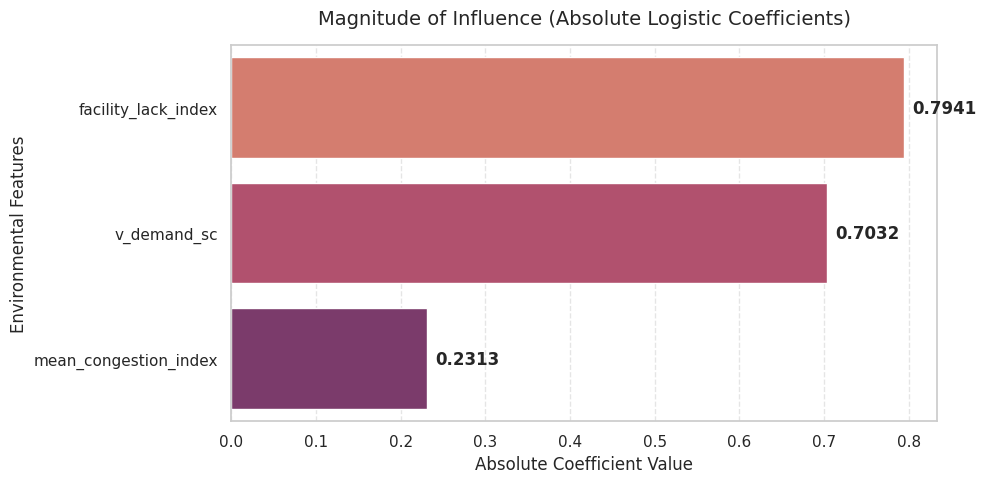

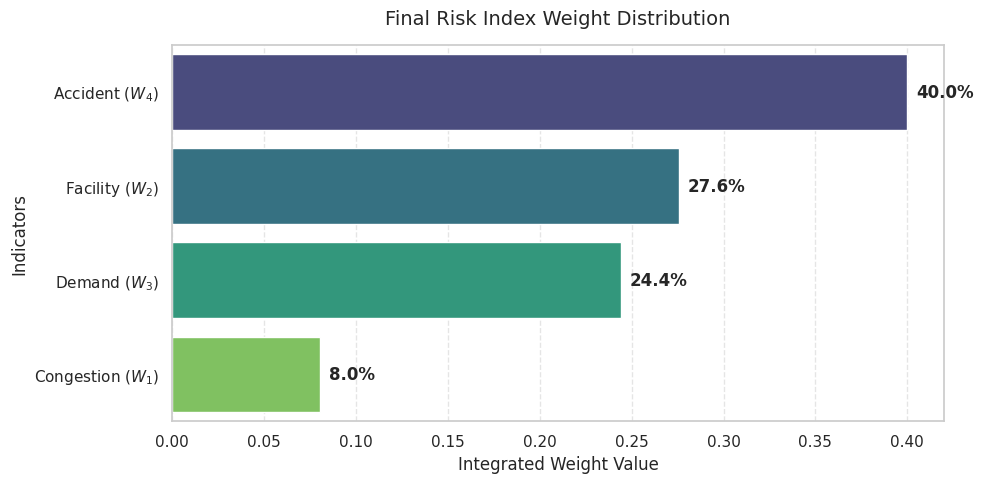

In [18]:
# 요약 및 시각화

# 분석요약
display(Markdown("---"))
display(Markdown("### ⚖️ 로짓 계수 기반 최종 가중치 산출 결과"))
display(df_logit_res[['지표명', 'Coefficient', 'Abs_Coef', 'Final_Weight']])

display(Markdown(f"""
**분석 결과 요약:**
- 로짓 회귀 결과 모든 변수가 통계적으로 매우 유의함($p < 0.05$)이 확인되었습니다.
- 데이터 분포 편향이 심한 엔트로피법 대신, 모델이 입증한 **통계적 영향력(계수 절대값)**을 가중치의 근거로 채택하였습니다.
- 이를 통해 '시설 미비' 변수의 기여도를 충분히 확보하여 정책적 대안 제시의 타당성을 높였습니다.

**최종 가중치 및 수식:**
- **교통 혼잡 가중치 ($w_1$):** `{w1:.4f}`
- **시설 미비 가중치 ($w_2$):** `{w2:.4f}`
- **취약 수요 가중치 ($w_3$):** `{w3:.4f}`
- **사고 이력 가중치 ($w_4$):** `{w4:.4f}` (Fixed)
- **최종 수식:**
> **`{final_formula}`**
- **파일 이름:** `current_risk_index.csv`
"""))
display(Markdown("---"))

display(Markdown(f"### 🏆 교통취약 현재위험도 산출 결과 (상위 10개)"))
display(result.head(10).style.background_gradient(cmap='YlOrRd', subset=['current_risk']))
display(Markdown("---"))

# 로짓 회귀계수 절대값 분포 (영향력의 크기)
plt.figure(figsize=(10, 5), facecolor='white')
plot_df = df_logit_res.sort_values('Abs_Coef', ascending=False)

sns.barplot(x='Abs_Coef', y='지표명', data=plot_df, palette='flare')
plt.title('Magnitude of Influence (Absolute Logistic Coefficients)', fontsize=14, pad=15)
plt.xlabel('Absolute Coefficient Value', fontsize=12)
plt.ylabel('Environmental Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

for i, v in enumerate(plot_df['Abs_Coef']):
    plt.text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


# 최종 통합 가중치 배분 (환경 0.6 : 사고 0.4)
plt.figure(figsize=(10, 5), facecolor='white')
weights_data = {
    'Indicator': ['Congestion ($W_1$)', 'Facility ($W_2$)', 'Demand ($W_3$)', 'Accident ($W_4$)'],
    'Weight': [w1, w2, w3, w4]
}
df_w = pd.DataFrame(weights_data)
df_w = df_w.sort_values('Weight', ascending=False)

sns.barplot(x='Weight', y='Indicator', data=df_w, palette='viridis')
plt.title('Final Risk Index Weight Distribution', fontsize=14, pad=15)
plt.xlabel('Integrated Weight Value', fontsize=12)
plt.ylabel('Indicators', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

for i, v in enumerate(df_w['Weight']):
    plt.text(v + 0.005, i, f'{v*100:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()